In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense


In [ ]:
zip_path = "/content/drive/MyDrive/SisFall_dataset_csv_annotated.zip"
extract_path = "/content/drive/MyDrive/SisFall_dataset_csv_annotated"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")


Dataset extracted


In [ ]:
files = [f for f in os.listdir(extract_path+"/SisFall_dataset_csv_annotated") if f.endswith(".csv")]

data_list = []
file_names = []

for file in files:
    full_path = os.path.join(extract_path+"/SisFall_dataset_csv_annotated", file)
    df = pd.read_csv(full_path)

    # Drop unnamed / index column safely
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    data_list.append(df)
    file_names.append(file)

print("Total files loaded:", len(data_list))
print("First 10 loaded file names:")
for name in file_names[:10]:
    print(name)


Total files loaded: 324
First 10 loaded file names:
D01_SA03_R01_annotated.csv
D01_SA04_R01_annotated.csv
D01_SA05_R01_annotated.csv
D01_SA06_R01_annotated.csv
D01_SA07_R01_annotated.csv
D01_SA08_R01_annotated.csv
D01_SA09_R01_annotated.csv
D01_SA10_R01_annotated.csv
D01_SA11_R01_annotated.csv
D01_SA12_R01_annotated.csv


In [ ]:
cleaned_data = []

for df in data_list:
    # Drop unnamed / empty column (index column)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # ALSO handle truly empty column name
    if df.columns[0] == '':
        df = df.iloc[:, 1:]

    cleaned_data.append(df)

data_list = cleaned_data


In [ ]:
print(data_list[0].columns)

Index(['acc1_x', 'acc1_y', 'acc1_z', 'gyro_x', 'gyro_y', 'gyro_z', 'acc2_x',
       'acc2_y', 'acc2_z', 'label'],
      dtype='object')


In [ ]:
WINDOW_SIZE = 200   # 1 second window
STEP_SIZE = 100     # 50% overlap

X = []
y = []

for df in data_list:
    signals = df[['acc1_x','acc1_y','acc1_z',
                  'gyro_x','gyro_y','gyro_z']].values

    label = df['label'].iloc[0]
    label = 1 if label == 2 else 0  # Fall=1, ADL=0

    for i in range(0, len(signals) - WINDOW_SIZE, STEP_SIZE):
        window = signals[i:i+WINDOW_SIZE]
        X.append(window)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Windows shape:", X.shape)
print("Labels shape:", y.shape)


Windows shape: (32975, 200, 6)
Labels shape: (32975,)


In [ ]:
scaler = StandardScaler()

X_reshaped = X.reshape(-1, 6)
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (26380, 200, 6)
Test: (6595, 200, 6)


In [ ]:
model = Sequential([
    Conv1D(8, 5, activation='relu', input_shape=(200, 6)),
    MaxPooling1D(2),

    Conv1D(16, 3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 196, 8)         │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,969 (50.66 KB)

 Trainable params: 12,969 (50.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)


Epoch 1/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8160 - loss: 0.3335 - val_accuracy: 0.9570 - val_loss: 0.1074
Epoch 2/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9638 - loss: 0.0937 - val_accuracy: 0.9706 - val_loss: 0.0769
Epoch 3/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9764 - loss: 0.0613 - val_accuracy: 0.9799 - val_loss: 0.0540
Epoch 4/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9816 - loss: 0.0487 - val_accuracy: 0.9807 - val_loss: 0.0537
Epoch 5/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9869 - loss: 0.0362 - val_accuracy: 0.9799 - val_loss: 0.0518
Epoch 6/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9857 - loss: 0.0355 - val_accuracy: 0.9829 - val_loss: 0.0475
Epoch 7/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9906 - loss: 0.0262 - val_accuracy: 0.9831 - val_loss: 0.0487
Epoch 8/15
660/660 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9911 - loss: 0.0261 - val_accurac

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9881 - loss: 0.0400
Test Accuracy: 0.9881728291511536


In [ ]:
import tensorflow as tf
import numpy as np

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

def representative_dataset():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_dataset

tflite_quant_model = converter.convert()

with open("sisfall_cnn_int8.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("INT8 model saved successfully!")


Saved artifact at '/tmp/tmpqdugy_m5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136997267177296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997267176528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136996881973712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136996881974864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136996881974672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136996881973520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136997267176144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136996881973904: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model saved successfully!


In [ ]:
with open("sisfall_cnn_int8.tflite", "rb") as f:
    data = f.read()

with open("model.h", "w") as f:
    f.write('#include <pgmspace.h>\n')
    f.write("const unsigned char model[] PROGMEM = {\n")

    for i, b in enumerate(data):
        if i % 12 == 0:
            f.write("\n ")
        f.write(f"0x{b:02x}, ")

    f.write("\n};\n")
    f.write(f"const unsigned int model_len = {len(data)};\n")

print("model.h generated correctly!")


model.h generated correctly!


In [ ]:
import os

size = os.path.getsize("sisfall_cnn_int8.tflite")
print("Model size (bytes):", size)
print("Model size (KB):", size / 1024)


Model size (bytes): 20056
Model size (KB): 19.5859375


In [ ]:
interpreter = tf.lite.Interpreter(model_path="sisfall_cnn_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype:", input_details[0]['dtype'])
print("Output dtype:", output_details[0]['dtype'])


Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()


209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[3526   75]
 [  20 3054]]


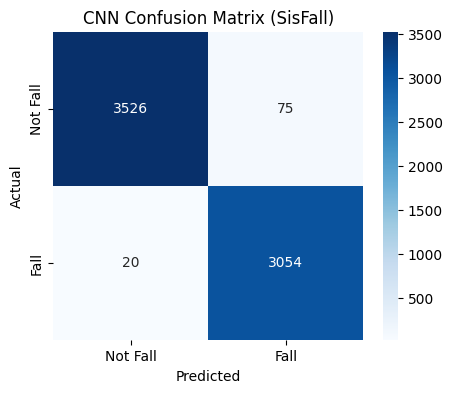

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fall", "Fall"],
    yticklabels=["Not Fall", "Fall"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix (SisFall)")
plt.show()


In [ ]:
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()


209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[3526   75]
 [  20 3054]]


In [ ]:
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)          # Sensitivity
f1_score  = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-score   : {f1_score:.4f}")


Accuracy   : 0.9858
Precision  : 0.9760
Recall     : 0.9935
F1-score   : 0.9847


In [ ]:
specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.4f}")


Specificity: 0.9792


In [ ]:
fpr = FP / (FP + TN)
print(f"False Positive Rate: {fpr:.4f}")


False Positive Rate: 0.0208


In [ ]:
fnr = FN / (FN + TP)
print(f"False Negative Rate: {fnr:.4f}")


False Negative Rate: 0.0065
